In [162]:
import pandas as pd
import os
import numpy as np
import math
import pytaxonkit
import subprocess
import json
import seaborn as sns
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
!datasets download virus genome accession "AF538689.1"  --include protein --filename "test-data.zip"

New version of client (18.29.0) available at https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/LATEST/linux-amd64/datasets.
Downloading: test-data.zip    4.07kB valid data package
Validating package files [================================================] 100% 5/5


In [3]:
!datasets summary taxonomy taxon "Barley"

Error: The taxonomy name 'Barley' is not exact. Try using one of the suggested taxids:
Barley yellow dwarf virus (species, taxid: 12037, viruses)
Barley stripe mosaic virus (no-rank, taxid: 12327, viruses)
Barley yellow dwarf virus-PAV (no-rank, taxid: 2169986, viruses)
Cytorhabdovirus hordei (no-rank, taxid: 1985699, Barley yellow striate mosaic virus)
Barley yellow dwarf virus-PAS (no-rank, taxid: 2169985, viruses)
Barley yellow mosaic virus (no-rank, taxid: 12465, viruses)
Barley virus G (no-rank, taxid: 1825924, viruses)
Barley dwarf virus (no-rank, taxid: 497862, viruses)
Barley yellow dwarf virus MAV (no-rank, taxid: 2169984, viruses)
Barley yellow dwarf virus GPV (no-rank, taxid: 2169980, Barley yellow dwarf virus - GPV)

Use datasets summary taxonomy taxon <command> --help for detailed help about a command.



In [4]:
def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index()
    count_df.columns=[column_name, count_column_name]
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    return count_df

def print_histogram(df, col_name, n_bins):
    sns.histplot(df[col_name])
    print(f"min seq len = {min(df[col_name])}")
    print(f"max seq len = {max(df[col_name])}")
    plt.show()
    
    freq, bins = np.histogram(df[col_name], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

def filter_with_threshold_percentage(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}")
    if n is None:
        n = df.shape[0]
    print(f"n= {n}")
    count_df = column_stats(df, column_name, n=n)
    percent_column_name = column_name + "_percent"
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [5]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429.csv")
df = pd.read_csv(dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (15731, 90)


Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species',
       'Genome Status', 'Strain', 'Serovar', 'Biovar', 'Pathovar', 'MLST',
       'Segment', 'Subtype', 'H_type', 'N_type', 'H1 Clade Global',
       'H1 Clade US', 'H5 Clade', 'pH1N1-like', 'Lineage', 'Clade', 'Subclade',
       'Other Typing', 'Culture Collection', 'Type Strain', 'Reference',
       'Genome Quality', 'Completion Date', 'Publication', 'Authors',
       'BioProject Accession', 'BioSample Accession', 'Assembly Accession',
       'SRA Accession', 'GenBank Accessions', 'Sequencing Center',
       'Sequencing Status', 'Sequencing Platform', 'Sequencing Depth',
       'Assembly Method', 'Chromosome', 'Plasmids', 'Contigs', 'Size',
       'GC Content', 'Contig L50', 'Contig N50', 'TRNA', 'RRNA', 'Mat Peptide',
       'CDS', 'Coarse Consistency', 'Fine Consistency', 'Ch

In [6]:
df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Host Age,Host Health,Host Group,Lab Host,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified
0,1000373.10,Rosellinia necatrix quadrivirus 1 W1118,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T11:05:04.123Z,2025-12-06T11:05:04.123Z
1,1000373.40,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.037Z,2025-12-06T08:01:47.037Z
2,1000373.50,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.164Z,2025-12-06T08:01:47.164Z
3,1000411.30,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:04:18.329Z,2021-01-23T22:04:18.329Z
4,1000411.40,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:06:18.856Z,2021-01-23T22:06:18.856Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15726,999729.23,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:40:21.986Z,2022-03-12T21:40:21.986Z
15727,999729.24,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:34:20.054Z,2022-03-12T21:34:20.054Z
15728,999729.25,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:49:25.104Z,2022-03-12T21:49:25.104Z
15729,999729.35,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-05-01T01:51:20.496Z,2022-05-01T01:51:20.496Z


In [7]:
df["Host Group"].value_counts()

Nonhuman Mammal    1395
Bacteria            882
Plant               779
Insect              770
Human               610
Avian               371
Tick                298
Lab                  79
Fish                 71
Reptile              35
Sea Mammal           25
Crustaceans          20
Amphibian             2
Fungi                 1
Name: Host Group, dtype: int64

In [8]:
df["Host Name"].nunique()

3771

In [9]:
df[df["Host Name"].isna()][["Genome Name", "GenBank Accessions"]]

,Genome Name,GenBank Accessions
33,Ljungan virus M1146,AF538689
35,Bos taurus papillomavirus 7,DQ217793
45,Simian sapelovirus 1 2383,NC_004451
46,Simian sapelovirus 1 2383,AY064708
47,Porcine sapelovirus 1 V13,AF406813
...,...,...
15631,Plutella xylostella granulovirus K1,AF270937
15633,Pseudomonas phage phi15,FR823298
15634,Tanapox virus TPV-Kenya,EF420156
15672,Titi monkey adenovirus ECC-2011,HQ913600


In [10]:
print(df["Host Name"].nunique())
print(df["Host Common Name"].nunique())

3771
369


In [11]:
print(sum(df["Host Name"].isna()))
print(sum(df["Host Common Name"].isna()))
print(sum(df["Host Name"].isna() & ~df["Host Common Name"].isna() ))

4349
10393
34


In [12]:
df[df["Host Name"].isna() & ~df["Host Common Name"].isna()][["Genome ID", "GenBank Accessions", "Host Name", "Host Common Name"]]

,Genome ID,GenBank Accessions,Host Name,Host Common Name
125,1.024541e+04,NC_006998,NaN,Lab host
126,1.025430e+04,AY243312,NaN,Lab host
519,1.078429e+04,NC_001540,NaN,Lab host
520,1.078829e+04,NC_001539,NaN,Lab host
521,1.079439e+04,NC_001510,NaN,Lab host
522,1.079440e+04,J02275,NaN,Lab host
951,1.133292e+06,JN939331,NaN,Lab host
952,1.133294e+06,JN939332,NaN,Lab host
1189,1.168745e+06,JQ797329,NaN,Lab host
2082,1.327970e+06,KC821606,NaN,Lab host


In [13]:
sum(~df["Host Name"].isna())

11382

In [14]:
df = df[~df["Host Name"].isna()]
df.shape

(11382, 90)

In [15]:
pytaxonkit.name2taxid(["Salmo salar"])

,Name,TaxID,Rank
0,Salmo salar,8030,species


In [16]:
!datasets summary taxonomy taxon "Salmo salar"

New version of client (18.29.0) available at https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/LATEST/linux-amd64/datasets.
{"reports": [{"query":["Salmo salar"],"taxonomy":{"classification":{"class":{"id":186623,"name":"Actinopteri"},"domain":{"id":2759,"name":"Eukaryota"},"family":{"id":8015,"name":"Salmonidae"},"genus":{"id":8028,"name":"Salmo"},"kingdom":{"id":33208,"name":"Metazoa"},"order":{"id":8006,"name":"Salmoniformes"},"phylum":{"id":7711,"name":"Chordata"},"species":{"id":8030,"name":"Salmo salar"}},"counts":[{"count":16,"type":"COUNT_TYPE_ASSEMBLY"},{"count":86726,"type":"COUNT_TYPE_GENE"},{"count":12199,"type":"COUNT_TYPE_tRNA"},{"count":20676,"type":"COUNT_TYPE_rRNA"},{"count":978,"type":"COUNT_TYPE_snRNA"},{"count":880,"type":"COUNT_TYPE_snoRNA"},{"count":43178,"type":"COUNT_TYPE_PROTEIN_CODING"},{"count":4861,"type":"COUNT_TYPE_ncRNA"},{"count":38,"type":"COUNT_TYPE_OTHER"}],"curator_common_name":"Atlantic salmon","current_scientific_name":{"authority":"Linnaeus, 

In [17]:
VERTEBRATA_TAX_ID = 7742

def get_host_metadata(host_names):
    host_metadata = {}
    error_hosts = []
    n = len(host_names)
    for i, host_name in enumerate(host_names):
        print(f"({i}) {host_name}")
        try: 
            output = subprocess.run(["datasets", "summary", "taxonomy", "taxon", host_name], capture_output=True)
            #tax_json = json.loads(output.stdout)["reports"][0]["taxonomy"]["classification"]
            output_json = json.loads(output.stdout)
            reports = output_json["reports"]
            report_count = int(output_json["total_count"])
            for report in reports:
                tax_json = report["taxonomy"]
                classification_json = tax_json["classification"]
                metadata = {}
                if "species" in classification_json:
                    metadata["species_tax_name"] = classification_json["species"]["name"]
                    metadata["species_tax_id"] = classification_json["species"]["id"]
    
                if "genus" in classification_json:
                    metadata["genus_tax_name"] = classification_json["genus"]["name"]
                    metadata["genus_tax_id"] = classification_json["genus"]["id"]
    
                if "family" in classification_json:
                    metadata["family_tax_name"] = classification_json["family"]["name"]
                    metadata["family_tax_id"] = classification_json["family"]["id"]
                
                if "order" in classification_json:
                    metadata["order_tax_name"] = classification_json["order"]["name"]
                    metadata["order_tax_id"] = classification_json["order"]["id"]

                if "class" in classification_json:
                    metadata["class_tax_name"] = classification_json["class"]["name"]
                    metadata["class_tax_id"] = classification_json["class"]["id"]
    
                parents = tax_json["parents"]
                if VERTEBRATA_TAX_ID in parents:
                    metadata["is_vertebrate"] = True
                else:
                    metadata["is_vertebrate"] = False
                    
                host_metadata[host_name] = metadata
                
        except Exception as e:
            error_hosts.append(host_name)
            print(e)
    return host_metadata, error_hosts

In [18]:
df["host_name_cleaned"] = df["Host Name"].apply(lambda x: " ".join(x.split(" ")[:2]))

/tmp/ipykernel_2395295/3428461402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["host_name_cleaned"] = df["Host Name"].apply(lambda x: " ".join(x.split(" ")[:2]))


In [19]:
df["Host Name"].nunique()

3771

In [20]:
df["Host Name"].value_counts()

Homo sapiens                           577
Mycobacterium smegmatis mc2 155        172
Escherichia coli                       131
Klebsiella pneumoniae                  118
Pseudomonas aeruginosa                  85
                                      ... 
Salmo salar l. (atlantic salmon)         1
Cicer arietinum voucher dar 76857        1
Cicer arietinum voucher brip 52877a      1
Cicer arietinum voucher brip 52878a      1
Digitaria didactyla willd                1
Name: Host Name, Length: 3771, dtype: int64

In [21]:
df["host_name_cleaned"].nunique()

2635

In [22]:
df["host_name_cleaned"].value_counts()

Homo sapiens               579
Escherichia coli           302
Mycobacterium smegmatis    183
Klebsiella pneumoniae      174
Pseudomonas aeruginosa     143
                          ... 
Feral pigeon                 1
Cercopithecus mitis          1
Datura inoxia                1
Ictalurus punctatus          1
Rhododendron maximum         1
Name: host_name_cleaned, Length: 2635, dtype: int64

In [23]:
hosts = df["host_name_cleaned"].unique()

In [ ]:
#host_metadata, error_hosts = get_host_metadata(hosts)

(0) Rosellinia necatrix
(1) Rodent
Expecting value: line 1 column 1 (char 0)
(2) Sandfly
Expecting value: line 1 column 1 (char 0)
(3) Homo sapiens
(4) mosquito
Expecting value: line 1 column 1 (char 0)
(5) Chilli
Expecting value: line 1 column 1 (char 0)
(6) Scalopus aquaticus
(7) Vernonia cinerea
(8) Perca fluviatilis
(9) Limnodynastes ornatus
(10) Gallus gallus
(11) Drosophila ananassae
(12) Diptera
(13) Sida sp.
(14) Shigella flexneri
(15) Hardenbergia comptoniana
(16) Spissistilus festinus
(17) Lutzomyia sp.
(18) Staphylococcus aureus
(19) Ipomoea batatas
(20) Ipomoea purpurea
(21) Ipomoea indica
(22) Rhodococcus equi
(23) Trichomonas vaginalis
(24) Triticum aestivum
(25) Ixodes (Trichotoixodes)
Expecting value: line 1 column 1 (char 0)
(26) Uria sp.
Expecting value: line 1 column 1 (char 0)
(27) Musa sp.
(28) Euphorbia heterophylla
(29) cutthroat trout
(30) Thysanoplusia orichalcea
(31) raccoon
(32) Columba livia
(33) sheep
(34) Solanum lycopersicum
(35) Stenotrophomonas maltophi

In [29]:
host_metadata_df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_host_metadata.csv"), index_col=0)
host_metadata = host_metadata_df.to_dict("index")
host_metadata
# host_metadata_df = pd.DataFrame(host_metadata).transpose()
# host_metadata_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_host_metadata.csv"))

In [27]:
host_metadata

{'Rosellinia necatrix': {'species_tax_name': 'Rosellinia necatrix',
  'species_tax_id': 77044,
  'genus_tax_name': 'Rosellinia',
  'genus_tax_id': 77043,
  'family_tax_name': 'Xylariaceae',
  'family_tax_id': 37990,
  'order_tax_name': 'Xylariales',
  'order_tax_id': 37989,
  'class_tax_name': 'Sordariomycetes',
  'class_tax_id': 147550,
  'is_vertebrate': False},
 'Homo sapiens': {'species_tax_name': 'Homo sapiens',
  'species_tax_id': 9606,
  'genus_tax_name': 'Homo',
  'genus_tax_id': 9605,
  'family_tax_name': 'Hominidae',
  'family_tax_id': 9604,
  'order_tax_name': 'Primates',
  'order_tax_id': 9443,
  'class_tax_name': 'Mammalia',
  'class_tax_id': 40674,
  'is_vertebrate': True},
 'Scalopus aquaticus': {'species_tax_name': 'Scalopus aquaticus',
  'species_tax_id': 71119,
  'genus_tax_name': 'Scalopus',
  'genus_tax_id': 71118,
  'family_tax_name': 'Talpidae',
  'family_tax_id': 9373,
  'order_tax_name': 'Eulipotyphla',
  'order_tax_id': 9362,
  'class_tax_name': 'Mammalia',
  '

In [30]:
len(host_metadata)

2192

In [31]:
df["virus_host_species_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_id") if x in host_metadata else None)

/tmp/ipykernel_2395295/3630995619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_id") if x in host_metadata else None)


In [32]:
df["virus_host_species_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2395295/3603374661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_name") if x in host_metadata else None)


In [33]:
df["virus_host_genus_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("genus_tax_id") if x in host_metadata else None)
df["virus_host_genus_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("genus_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2395295/1487496712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_genus_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("genus_tax_id") if x in host_metadata else None)
/tmp/ipykernel_2395295/1487496712.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_genus_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("genus_tax_name") if x in host_metadata else None)


In [34]:
df["virus_host_family_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("family_tax_id") if x in host_metadata else None)
df["virus_host_family_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("family_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2395295/1907349873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_family_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("family_tax_id") if x in host_metadata else None)
/tmp/ipykernel_2395295/1907349873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_family_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("family_tax_name") if x in host_metadata else None)


In [35]:
df["virus_host_order_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("order_tax_id") if x in host_metadata else None)
df["virus_host_order_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("order_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2395295/3640027596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_order_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("order_tax_id") if x in host_metadata else None)
/tmp/ipykernel_2395295/3640027596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_order_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("order_tax_name") if x in host_metadata else None)


In [36]:
df["virus_host_class_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("class_tax_id") if x in host_metadata else None)
df["virus_host_class_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("class_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2395295/3783251975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_class_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("class_tax_id") if x in host_metadata else None)
/tmp/ipykernel_2395295/3783251975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_class_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("class_tax_name") if x in host_metadata else None)


In [37]:
df["virus_host_is_vertebrate"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("is_vertebrate") if x in host_metadata else None)

/tmp/ipykernel_2395295/3631739729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_is_vertebrate"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("is_vertebrate") if x in host_metadata else None)


#### Remove records with virus host is NOT a vertebrate

In [38]:
df["virus_host_is_vertebrate"].value_counts()

False    6995
True     3214
Name: virus_host_is_vertebrate, dtype: int64

In [39]:
df = df[df["virus_host_is_vertebrate"] == True]
df.shape

(3214, 102)

#### Remove records with virus_genus_tax_name == NULL

In [40]:
df = df[~df["Genus"].isna()]
df.shape

(3041, 102)

In [41]:
base_df = df 
base_df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_species_tax_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate
9,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,Homo sapiens,9605.0,Homo,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
10,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,Homo sapiens,9605.0,Homo,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
11,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,Homo sapiens,9605.0,Homo,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
12,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,Homo sapiens,9605.0,Homo,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
13,1000646.7,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,Homo sapiens,9605.0,Homo,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15711,994995.9,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,Gallus gallus,9030.0,Gallus,9005.0,Phasianidae,8976.0,Galliformes,8782.0,Aves,True
15712,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,Macaca fascicularis,9539.0,Macaca,9527.0,Cercopithecidae,9443.0,Primates,40674.0,Mammalia,True
15717,996650.4,Camelus dromedarius papillomavirus 1,NaN,996650,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,Camelus dromedarius,9836.0,Camelus,9835.0,Camelidae,91561.0,Artiodactyla,40674.0,Mammalia,True
15718,996651.4,Camelus dromedarius papillomavirus 2,NaN,996651,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,Camelus dromedarius,9836.0,Camelus,9835.0,Camelidae,91561.0,Artiodactyla,40674.0,Mammalia,True


In [42]:
proteomes_proteins_dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins.csv")
proteomes_proteins_df = pd.read_csv(proteomes_proteins_dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {proteomes_proteins_df.shape}")
proteomes_proteins_df.columns

Dataset size: (512344, 4)


Index(['proteome_id', 'protein_id', 'sequence', 'protein'], dtype='object')

## HOST: Species

In [163]:
base_df[base_df["virus_host_species_tax_id"].isna()]

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_species_tax_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate
249,1.040738e+04,Hepatitis B virus gor97,NaN,10407,10239;2559587;2732397;2732409;2732514;2732515;...,Viruses;Riboviria;Pararnavirae;Artverviricota;...,Viruses,Pararnavirae,Artverviricota,Revtraviricetes,...,None,9592.0,Gorilla,9604.0,Hominidae,9443.0,Primates,40674.0,Mammalia,True
879,1.124250e+04,Rinderpest virus (strain Kabete O) Kabete 'O' ...,NaN,11242,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,9903.0,Bos,9895.0,Bovidae,91561.0,Artiodactyla,40674.0,Mammalia,True
880,1.124260e+04,Rinderpest virus (strain Kabete O) Kabete 'O' ...,NaN,11242,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,9903.0,Bos,9895.0,Bovidae,91561.0,Artiodactyla,40674.0,Mammalia,True
1733,1.256869e+06,Egli virus 18/193,NaN,1256869,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,8165.0,Percidae,8111.0,Perciformes,186623.0,Actinopteri,True
2234,1.374431e+05,Macropodid alphaherpesvirus 1 MaHV1.3076/08,NaN,137443,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,None,NaN,None,9307.0,Macropodidae,38609.0,Diprotodontia,40674.0,Mammalia,True
2235,1.374439e+05,Macropodid alphaherpesvirus 1 MaHV1.3076/08,NaN,137443,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,None,NaN,None,9307.0,Macropodidae,38609.0,Diprotodontia,40674.0,Mammalia,True
3105,1.549865e+06,Tilapia lake virus Til-4-2011,NaN,1549864,10239;2559587;2732396;2497569;2497571;2497577;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Insthoviricetes,...,None,8126.0,Tilapia,8113.0,Cichlidae,1489911.0,Cichliformes,186623.0,Actinopteri,True
3106,1.549865e+06,Tilapia lake virus Til-4-2011,NaN,1549864,10239;2559587;2732396;2497569;2497571;2497577;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Insthoviricetes,...,None,8126.0,Tilapia,8113.0,Cichlidae,1489911.0,Cichliformes,186623.0,Actinopteri,True
3107,1.549865e+06,Tilapia lake virus Til-4-2011,NaN,1549864,10239;2559587;2732396;2497569;2497571;2497577;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Insthoviricetes,...,None,8126.0,Tilapia,8113.0,Cichlidae,1489911.0,Cichliformes,186623.0,Actinopteri,True
3108,1.549865e+06,Tilapia lake virus Til-4-2011,NaN,1549864,10239;2559587;2732396;2497569;2497571;2497577;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Insthoviricetes,...,None,8126.0,Tilapia,8113.0,Cichlidae,1489911.0,Cichliformes,186623.0,Actinopteri,True


In [164]:
set(df["host_name_cleaned"].unique()) - set(host_metadata.keys())

set()

In [165]:
df = base_df[~base_df["virus_host_species_tax_id"].isna()]
df.shape

(2998, 102)

In [166]:
df["virus_host_species_tax_id"] = df["virus_host_species_tax_id"].astype(int)

/tmp/ipykernel_2395295/3419116339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_id"] = df["virus_host_species_tax_id"].astype(int)


In [167]:
df["virus_host_species_tax_id"].nunique()

548

In [168]:
print(df["virus_host_species_tax_id"].nunique())
column_stats(df, "virus_host_species_tax_name")

548
Number of unique values = 548


,virus_host_species_tax_name,virus_host_species_tax_name_count,virus_host_species_tax_name_percent
0,Homo sapiens,575,19.179453
1,Gallus gallus,145,4.836558
2,Sus scrofa,84,2.801868
3,Bos taurus,63,2.101401
4,Equus caballus,42,1.400934
...,...,...,...
543,Lagothrix lagotricha,1,0.033356
544,Falco sparverius,1,0.033356
545,Oligoryzomys flavescens,1,0.033356
546,Oligoryzomys longicaudatus,1,0.033356


In [169]:
column_stats(df, "virus_host_species_tax_id")[:10]

Number of unique values = 548


,virus_host_species_tax_id,virus_host_species_tax_id_count,virus_host_species_tax_id_percent
0,9606,575,19.179453
1,9031,145,4.836558
2,9823,84,2.801868
3,9913,63,2.101401
4,9796,42,1.400934
5,10116,41,1.367578
6,9612,39,1.300867
7,8574,34,1.134089
8,10090,28,0.933956
9,9598,28,0.933956


In [170]:
column_stats(df, "Genus")

Number of unique values = 361


,Genus,Genus_count,Genus_percent
0,Orthoreovirus,183,6.104069
1,Mastadenovirus,106,3.535690
2,Alphapolyomavirus,101,3.368913
3,Rotavirus,94,3.135424
4,Phlebovirus,91,3.035357
...,...,...,...
356,Kopavirus,1,0.033356
357,Kappatorquevirus,1,0.033356
358,Epsilonpapillomavirus,1,0.033356
359,Paundivirus,1,0.033356


min seq len = 1
max seq len = 1306


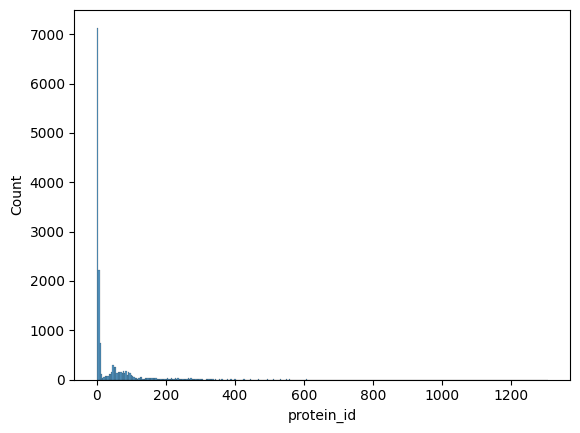

      start      end  count  percentage
0      1.00    14.05  10211   69.372919
1     14.05    27.10    188    1.277261
2     27.10    40.15    305    2.072152
3     40.15    53.20    749    5.088661
4     53.20    66.25    592    4.022012
..      ...      ...    ...         ...
95  1240.75  1253.80      0    0.000000
96  1253.80  1266.85      0    0.000000
97  1266.85  1279.90      0    0.000000
98  1279.90  1292.95      0    0.000000
99  1292.95  1306.00      1    0.006794

[100 rows x 4 columns]


In [171]:
print_histogram(pd.DataFrame(proteomes_proteins_df[["proteome_id", "protein_id"]].groupby("proteome_id").agg("count")).reset_index(), "protein_id", 100)

In [172]:
merged_df = pd.merge(df, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
merged_df.shape

(35865, 106)

min seq len = 1
max seq len = 274


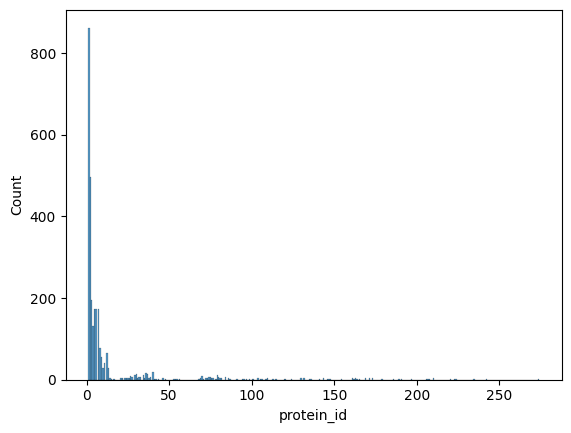

     start     end  count  percentage
0     1.00    3.73   1553   54.491228
1     3.73    6.46    480   16.842105
2     6.46    9.19    305   10.701754
3     9.19   11.92     68    2.385965
4    11.92   14.65     99    3.473684
..     ...     ...    ...         ...
95  260.35  263.08      0    0.000000
96  263.08  265.81      0    0.000000
97  265.81  268.54      0    0.000000
98  268.54  271.27      0    0.000000
99  271.27  274.00      2    0.070175

[100 rows x 4 columns]


In [173]:
print_histogram(pd.DataFrame(merged_df[["proteome_id", "protein_id"]].groupby("proteome_id").agg("count")).reset_index(), "protein_id", 100)

In [174]:
df_one_percent_prevelance = filter_with_threshold_percentage(df, "virus_host_species_tax_id", 1, n=df.shape[0])

Size of df = (2998, 102)
n= 2998
Number of unique values = 548
Size of filtered df = (1023, 102)
Number of unique values = 8


In [175]:
column_stats(df_one_percent_prevelance, "virus_host_species_tax_id", n=df.shape[0])

Number of unique values = 8


,virus_host_species_tax_id,virus_host_species_tax_id_count,virus_host_species_tax_id_percent
0,9606,575,19.179453
1,9031,145,4.836558
2,9823,84,2.801868
3,9913,63,2.101401
4,9796,42,1.400934
5,10116,41,1.367578
6,9612,39,1.300867
7,8574,34,1.134089


In [176]:
column_stats(df_one_percent_prevelance, "Species", n=df.shape[0])

Number of unique values = 412


,Species,Species_count,Species_percent
0,Alphainfluenzavirus influenzae,45,1.501001
1,Mastadenovirus dominans,24,0.800534
2,Rotavirus phigastroenteritidis,22,0.733823
3,Rotavirus deltagastroenteritidis,22,0.733823
4,Orbivirus orungoense,20,0.667111
...,...,...,...
407,Alphavirus rossriver,1,0.033356
408,Rubivirus rubellae,1,0.033356
409,Porcine astrovirus 4,1,0.033356
410,Aglavirus caranthi,1,0.033356


In [177]:
column_stats(df_one_percent_prevelance, "Genus", n=df.shape[0])

Number of unique values = 147


,Genus,Genus_count,Genus_percent
0,Rotavirus,70,2.334890
1,Gammapapillomavirus,57,1.901268
2,Phlebovirus,50,1.667779
3,Alphainfluenzavirus,45,1.501001
4,Orbivirus,41,1.367578
...,...,...,...
142,Erbovirus,1,0.033356
143,Sapelovirus,1,0.033356
144,Pipapillomavirus,1,0.033356
145,Avihepevirus,1,0.033356


In [178]:
merged_df_one_percent_prevelance = pd.merge(df_one_percent_prevelance, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
print(merged_df_one_percent_prevelance.shape)
merged_df_one_percent_prevelance.columns

(9793, 106)


Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class',
       ...
       'virus_host_family_tax_name', 'virus_host_order_tax_id',
       'virus_host_order_tax_name', 'virus_host_class_tax_id',
       'virus_host_class_tax_name', 'virus_host_is_vertebrate', 'proteome_id',
       'protein_id', 'sequence', 'protein'],
      dtype='object', length=106)

In [179]:
merged_df_one_percent_prevelance["proteome_id"].nunique()

944

In [180]:
column_stats(merged_df_one_percent_prevelance, "Species", n=df.shape[0])

Number of unique values = 393


,Species,Species_count,Species_percent
0,Asfivirus haemorrhagiae,1446,48.232155
1,Mastadenovirus dominans,911,30.386925
2,Orthopoxvirus akhmetapox,440,14.676451
3,Aviadenovirus hepatitidis,231,7.705137
4,Mardivirus gallidalpha3,200,6.671114
...,...,...,...
388,Orthohantavirus sinnombreense,1,0.033356
389,Pestivirus ratti,1,0.033356
390,Protoambidensovirus incertum3,1,0.033356
391,Porcine teschovirus 15,1,0.033356


In [181]:
column_stats(merged_df_one_percent_prevelance, "Genus", n=df.shape[0])

Number of unique values = 143


,Genus,Genus_count,Genus_percent
0,Asfivirus,1446,48.232155
1,Mastadenovirus,1410,47.031354
2,Varicellovirus,831,27.718479
3,Orthopoxvirus,619,20.647098
4,Aviadenovirus,519,17.311541
...,...,...,...
138,Inpeasmacovirus,2,0.066711
139,Nauglamirvirus,2,0.066711
140,Parabovirus,1,0.033356
141,Protoambidensovirus,1,0.033356


In [182]:
merged_df_one_percent_prevelance["protein"] = merged_df_one_percent_prevelance["protein"].apply(lambda x: str(x).replace(" ", "-").replace(",", "-"))
merged_df_one_percent_prevelance["protein_id_name"] = merged_df_one_percent_prevelance["protein_id"] + "_" + merged_df_one_percent_prevelance["protein"]
merged_df_one_percent_prevelance

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate,proteome_id,protein_id,sequence,protein,protein_id_name
0,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119410,AEA30058.1,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,L-protein,AEA30058.1_L-protein
1,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119411,AEA30046.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,AEA30046.1_polyprotein
2,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30072.1,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,nonstructural-protein,AEA30072.1_nonstructural-protein
3,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30073.1,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,nucleocapsid,AEA30073.1_nucleocapsid
4,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,NC_055341,YP_010086120.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,YP_010086120.1_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,994995.6,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,8976.0,Galliformes,8782.0,Aves,True,JQ920006,AFL91895.1,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,VP4,AFL91895.1_VP4
9789,994995.7,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,8976.0,Galliformes,8782.0,Aves,True,JQ920007,AFL91896.1,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,VP7,AFL91896.1_VP7
9790,994995.8,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,8976.0,Galliformes,8782.0,Aves,True,JQ920008,AFL91897.1,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,NSP1-1,AFL91897.1_NSP1-1
9791,994995.8,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,8976.0,Galliformes,8782.0,Aves,True,JQ920008,AFL91898.1,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,NSP1-2,AFL91898.1_NSP1-2


In [183]:
merged_df_one_percent_prevelance["protein_id_name"]

0                   AEA30058.1_L-protein
1                 AEA30046.1_polyprotein
2       AEA30072.1_nonstructural-protein
3                AEA30073.1_nucleocapsid
4             YP_010086120.1_polyprotein
                      ...               
9788                      AFL91895.1_VP4
9789                      AFL91896.1_VP7
9790                   AFL91897.1_NSP1-1
9791                   AFL91898.1_NSP1-2
9792                     AFL91899.1_NSP2
Name: protein_id_name, Length: 9793, dtype: object

In [184]:
clean_df = merged_df_one_percent_prevelance[["proteome_id", "protein_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_host_species_tax_name", "Genus", "Species", "sequence"]].rename(columns={"Genus": "virus_genus_tax_name", "Species": "virus_species_tax_name"})
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
...,...,...,...,...,...,...,...,...,...
9788,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...
9789,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...
9790,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...
9791,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...


#### Remove nucleotide sequences (noisy data). Sometimes the NCBI tool returns nucleotide sequences (reason unknown).

In [185]:
clean_df["is_nucleotide"] = clean_df["sequence"].apply(lambda x: sorted(set(x)) == ["A", "C", "G", "T"])

In [186]:
clean_df["is_nucleotide"].value_counts()

False    9655
True      138
Name: is_nucleotide, dtype: int64

In [187]:
clean_df = clean_df[clean_df["is_nucleotide"] == False]
print(clean_df["is_nucleotide"].value_counts())
clean_df.shape

False    9655
Name: is_nucleotide, dtype: int64


(9655, 10)

In [188]:
print(clean_df["proteome_id"].nunique())
clean_df["virus_species_tax_name"].nunique()

935


390

#### Drop all duplicated 'protein_id_names'

In [189]:
clean_df = clean_df.drop_duplicates(subset="protein_id_name", keep=False)
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
9788,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,False
9789,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,False
9790,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,False
9791,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,False


In [191]:
sum(clean_df["virus_species_tax_name"].isna())

0

In [74]:
clean_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_species_prevalence_gte_onepercent.csv"), index=False)

In [75]:
clean_df["sequence_length"] = clean_df["sequence"].apply(lambda x: len(x))

min seq len = 8
max seq len = 7141


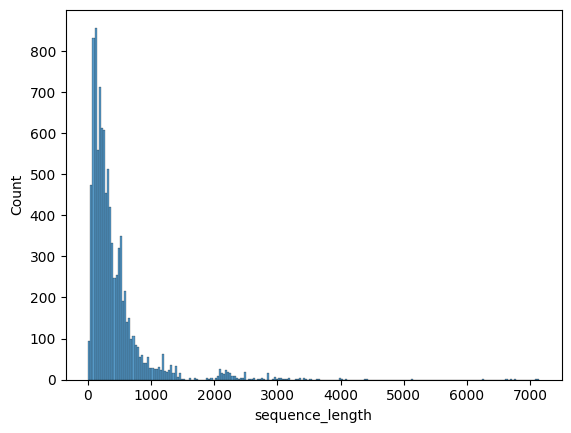

    start     end  count  percentage
0     8.0   721.3   8478   87.946058
1   721.3  1434.6    856    8.879668
2  1434.6  2147.9    101    1.047718
3  2147.9  2861.2    139    1.441909
4  2861.2  3574.5     44    0.456432
5  3574.5  4287.8     10    0.103734
6  4287.8  5001.1      2    0.020747
7  5001.1  5714.4      1    0.010373
8  5714.4  6427.7      1    0.010373
9  6427.7  7141.0      8    0.082988


In [76]:
print_histogram(clean_df, "sequence_length", 10)

## HOST: Genus

In [77]:
base_df[base_df["virus_host_genus_tax_id"].isna()]

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_species_tax_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate
1733,1256869.31,Egli virus 18/193,NaN,1256869,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,8165.0,Percidae,8111.0,Perciformes,186623.0,Actinopteri,True
2234,137443.10,Macropodid alphaherpesvirus 1 MaHV1.3076/08,NaN,137443,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,None,NaN,None,9307.0,Macropodidae,38609.0,Diprotodontia,40674.0,Mammalia,True
2235,137443.90,Macropodid alphaherpesvirus 1 MaHV1.3076/08,NaN,137443,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,None,NaN,None,9307.0,Macropodidae,38609.0,Diprotodontia,40674.0,Mammalia,True
4500,179986.40,Sea trout perhabdovirus 18/203,NaN,179986,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,8165.0,Percidae,8111.0,Perciformes,186623.0,Actinopteri,True
5211,1908804.40,Tetraparvovirus sp. tetra-CA1,NaN,1908804,10239;2731342;2732092;2732415;2732422;2732534;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Quintoviricetes,...,None,NaN,None,9850.0,Cervidae,91561.0,Artiodactyla,40674.0,Mammalia,True
9043,2560314.30,Avian metaavulavirus 20 APMV-20/gull/Kazakhsta...,NaN,2560314,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,8910.0,Laridae,8906.0,Charadriiformes,8782.0,Aves,True
9044,2560314.40,Avian metaavulavirus 20 APMV-20/gull/Kazakhsta...,NaN,2560314,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,8910.0,Laridae,8906.0,Charadriiformes,8782.0,Aves,True
9058,2560320.50,Avian orthoavulavirus 12 APMV-12/Anseriformes/...,NaN,2560320,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,NaN,None,8826.0,Anseriformes,8782.0,Aves,True
11922,3075194.40,Simian adenovirus GZ2-7 SAdV GZ2-7,NaN,3075194,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,None,NaN,None,9577.0,Hylobatidae,9443.0,Primates,40674.0,Mammalia,True
13172,400121.60,Gull circovirus,NaN,400121,10239;2731342;2732092;2732416;2732423;2732536;...,Viruses;Monodnaviria;Shotokuvirae;Cressdnaviri...,Viruses,Shotokuvirae,Cressdnaviricota,Arfiviricetes,...,None,NaN,None,8910.0,Laridae,8906.0,Charadriiformes,8782.0,Aves,True


In [78]:
set(base_df["host_name_cleaned"].unique()) - set(host_metadata.keys())

set()

In [79]:
df = base_df[~base_df["virus_host_genus_tax_id"].isna()]
print(df.shape)
df["virus_host_genus_tax_id"] = df["virus_host_genus_tax_id"].astype(int)
print(df["virus_host_genus_tax_id"].nunique())

(3031, 102)
371


/tmp/ipykernel_2395295/2034860110.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_genus_tax_id"] = df["virus_host_genus_tax_id"].astype(int)


In [80]:
column_stats(df, "virus_host_genus_tax_name")

Number of unique values = 371


,virus_host_genus_tax_name,virus_host_genus_tax_name_count,virus_host_genus_tax_name_percent
0,Homo,575,18.970637
1,Gallus,145,4.783900
2,Bos,92,3.035302
3,Sus,84,2.771363
4,Pteropus,79,2.606401
...,...,...,...
366,Chelonia,1,0.032992
367,Cynopterus,1,0.032992
368,Lagothrix,1,0.032992
369,Delphinus,1,0.032992


In [81]:
column_stats(df, "virus_host_genus_tax_id")[:10]

Number of unique values = 371


,virus_host_genus_tax_id,virus_host_genus_tax_id_count,virus_host_genus_tax_id_percent
0,9605,575,18.970637
1,9030,145,4.783900
2,9903,92,3.035302
3,9822,84,2.771363
4,9401,79,2.606401
5,10114,56,1.847575
6,9789,54,1.781590
7,9539,49,1.616628
8,49442,44,1.451666
9,10088,43,1.418674


In [82]:
column_stats(df, "Genus")

Number of unique values = 364


,Genus,Genus_count,Genus_percent
0,Orthoreovirus,183,6.037611
1,Mastadenovirus,106,3.497196
2,Alphapolyomavirus,101,3.332234
3,Rotavirus,94,3.101287
4,Phlebovirus,91,3.002309
...,...,...,...
359,Betanodavirus,1,0.032992
360,Orthotulasvirus,1,0.032992
361,Bonzesmacovirus,1,0.032992
362,Bovismacovirus,1,0.032992


In [83]:
merged_df = pd.merge(df, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
merged_df.shape

(36029, 106)

min seq len = 1
max seq len = 274


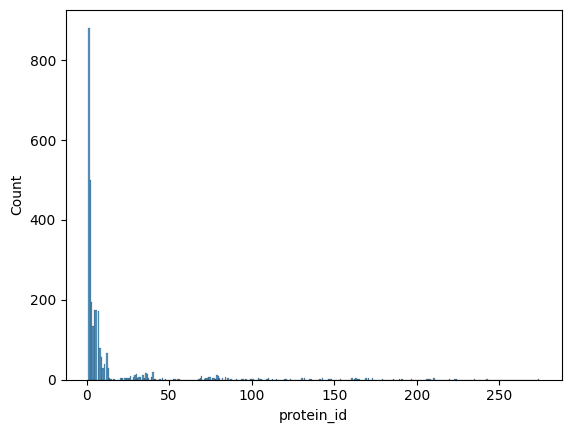

     start     end  count  percentage
0     1.00    3.73   1575   54.668518
1     3.73    6.46    484   16.799722
2     6.46    9.19    308   10.690732
3     9.19   11.92     68    2.360292
4    11.92   14.65    100    3.471017
..     ...     ...    ...         ...
95  260.35  263.08      0    0.000000
96  263.08  265.81      0    0.000000
97  265.81  268.54      0    0.000000
98  268.54  271.27      0    0.000000
99  271.27  274.00      2    0.069420

[100 rows x 4 columns]


In [84]:
print_histogram(pd.DataFrame(merged_df[["proteome_id", "protein_id"]].groupby("proteome_id").agg("count")).reset_index(), "protein_id", 100)

In [88]:
df_c8 = filter_with_threshold_percentage(df, "virus_host_genus_tax_id", 1.5, n=df.shape[0])

Size of df = (3031, 102)
n= 3031
Number of unique values = 371
Size of filtered df = (1134, 102)
Number of unique values = 8


In [89]:
column_stats(df_c8, "virus_host_genus_tax_id", n=df.shape[0])
#column_stats(df_two_percent_prevelance, "virus_host_genus_tax_id", n=df.shape[0])

Number of unique values = 8


,virus_host_genus_tax_id,virus_host_genus_tax_id_count,virus_host_genus_tax_id_percent
0,9605,575,18.970637
1,9030,145,4.783900
2,9903,92,3.035302
3,9822,84,2.771363
4,9401,79,2.606401
5,10114,56,1.847575
6,9789,54,1.781590
7,9539,49,1.616628


In [90]:
merged_c8_df = pd.merge(df_c8, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
print(merged_c8_df.shape)

(13444, 106)


In [91]:
merged_c8_df.columns

Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class',
       ...
       'virus_host_family_tax_name', 'virus_host_order_tax_id',
       'virus_host_order_tax_name', 'virus_host_class_tax_id',
       'virus_host_class_tax_name', 'virus_host_is_vertebrate', 'proteome_id',
       'protein_id', 'sequence', 'protein'],
      dtype='object', length=106)

In [92]:
merged_c8_df["proteome_id"].nunique()

1055

In [93]:
column_stats(merged_c8_df, "Species", n=df.shape[0])

Number of unique values = 450


,Species,Species_count,Species_percent
0,Asfivirus haemorrhagiae,1446,47.707027
1,Mastadenovirus dominans,911,30.056087
2,Cytomegalovirus macacinebeta8,548,18.079842
3,Orthopoxvirus akhmetapox,440,14.516661
4,Orthopoxvirus abatinomacacapox,416,13.724843
...,...,...,...
445,Avisivirus Pf-CHK1/AsV,1,0.032992
446,Hunnivirus 05VZ,1,0.032992
447,Human cosavirus,1,0.032992
448,WUHARV Sapelovirus 1,1,0.032992


In [94]:
column_stats(merged_c8_df, "Genus", n=df.shape[0])

Number of unique values = 152


,Genus,Genus_count,Genus_percent
0,Mastadenovirus,1670,55.097328
1,Asfivirus,1446,47.707027
2,Orthopoxvirus,1035,34.147146
3,Cytomegalovirus,944,31.144837
4,Varicellovirus,919,30.320026
...,...,...,...
147,Parabovirus,2,0.065985
148,Tambotovirus,2,0.065985
149,Dependoparvovirus,2,0.065985
150,Inpeasmacovirus,2,0.065985


In [95]:
merged_c8_df["protein"] = merged_c8_df["protein"].apply(lambda x: str(x).replace(" ", "-").replace(",", "-"))
merged_c8_df["protein_id_name"] = merged_c8_df["protein_id"] + "_" + merged_c8_df["protein"]
merged_c8_df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate,proteome_id,protein_id,sequence,protein,protein_id_name
0,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119410,AEA30058.1,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,L-protein,AEA30058.1_L-protein
1,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119411,AEA30046.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,AEA30046.1_polyprotein
2,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30072.1,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,nonstructural-protein,AEA30072.1_nonstructural-protein
3,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30073.1,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,nucleocapsid,AEA30073.1_nucleocapsid
4,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,NC_055341,YP_010086120.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,YP_010086120.1_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13439,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39826.1,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...,E4-orf6,ADZ39826.1_E4-orf6
13440,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39827.1,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...,E4-orf4,ADZ39827.1_E4-orf4
13441,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39828.1,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...,E4-orf3,ADZ39828.1_E4-orf3
13442,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39829.1,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...,E4-orf2,ADZ39829.1_E4-orf2


In [96]:
merged_c8_df["protein_id_name"]


0                    AEA30058.1_L-protein
1                  AEA30046.1_polyprotein
2        AEA30072.1_nonstructural-protein
3                 AEA30073.1_nucleocapsid
4              YP_010086120.1_polyprotein
                       ...               
13439                  ADZ39826.1_E4-orf6
13440                  ADZ39827.1_E4-orf4
13441                  ADZ39828.1_E4-orf3
13442                  ADZ39829.1_E4-orf2
13443                  ADZ39830.1_E4-orf1
Name: protein_id_name, Length: 13444, dtype: object

In [97]:
clean_df = merged_c8_df[["proteome_id", "protein_id", "protein", "protein_id_name", "virus_host_genus_tax_id", "virus_host_genus_tax_name", "Genus", "Species", "sequence"]].rename(columns={"Genus": "virus_genus_tax_name", "Species": "virus_species_tax_name"})
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9605,Homo,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
...,...,...,...,...,...,...,...,...,...
13439,HQ241818,ADZ39826.1,E4-orf6,ADZ39826.1_E4-orf6,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...
13440,HQ241818,ADZ39827.1,E4-orf4,ADZ39827.1_E4-orf4,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...
13441,HQ241818,ADZ39828.1,E4-orf3,ADZ39828.1_E4-orf3,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...
13442,HQ241818,ADZ39829.1,E4-orf2,ADZ39829.1_E4-orf2,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...


In [98]:
clean_df["is_nucleotide"] = clean_df["sequence"].apply(lambda x: sorted(set(x)) == ["A", "C", "G", "T"])
clean_df["is_nucleotide"].value_counts()

False    13303
True       141
Name: is_nucleotide, dtype: int64

In [99]:
clean_df = clean_df[clean_df["is_nucleotide"] == False]
print(clean_df["is_nucleotide"].value_counts())
clean_df.shape

False    13303
Name: is_nucleotide, dtype: int64


(13303, 10)

In [100]:
print(clean_df["proteome_id"].nunique())
clean_df["virus_species_tax_name"].nunique()

1044


445

In [101]:
clean_df = clean_df.drop_duplicates(subset="protein_id_name", keep=False)
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9605,Homo,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9605,Homo,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
13439,HQ241818,ADZ39826.1,E4-orf6,ADZ39826.1_E4-orf6,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...,False
13440,HQ241818,ADZ39827.1,E4-orf4,ADZ39827.1_E4-orf4,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...,False
13441,HQ241818,ADZ39828.1,E4-orf3,ADZ39828.1_E4-orf3,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...,False
13442,HQ241818,ADZ39829.1,E4-orf2,ADZ39829.1_E4-orf2,9539,Macaca,Mastadenovirus,Mastadenovirus simiae,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...,False


In [102]:
clean_df["proteome_id"].nunique()

1044

In [103]:
clean_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_genus_c8.csv"), index=False)

min seq len = 8
max seq len = 7141


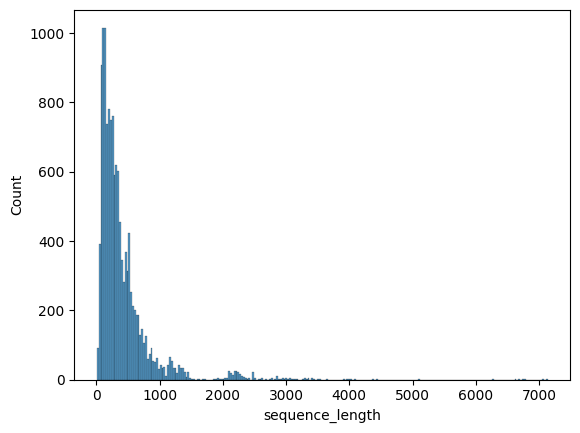

    start     end  count  percentage
0     8.0   721.3  11671   87.831126
1   721.3  1434.6   1256    9.452137
2  1434.6  2147.9    111    0.835340
3  2147.9  2861.2    174    1.309452
4  2861.2  3574.5     53    0.398856
5  3574.5  4287.8     11    0.082781
6  4287.8  5001.1      2    0.015051
7  5001.1  5714.4      1    0.007526
8  5714.4  6427.7      1    0.007526
9  6427.7  7141.0      8    0.060205


In [104]:
clean_df["sequence_length"] = clean_df["sequence"].apply(lambda x: len(x))
print_histogram(clean_df, "sequence_length", 10)

In [105]:
clean_df[["virus_host_genus_tax_id", "virus_host_genus_tax_name"]].value_counts()

virus_host_genus_tax_id  virus_host_genus_tax_name
9605                     Homo                         4330
9539                     Macaca                       2940
9822                     Sus                          1984
9030                     Gallus                       1203
9789                     Equus                        1047
9903                     Bos                           891
9401                     Pteropus                      669
10114                    Rattus                        224
dtype: int64

## HOST: Family

In [106]:
base_df[base_df["virus_host_family_tax_id"].isna()]

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_species_tax_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate
7900,2249930.3,Ashy storm petrel gyrovirus a12a1_528,NaN,2249930,10239;2731342;2732092;3412625;3412723;3420546;...,Viruses;Monodnaviria;Shotokuvirae;Commensaviri...,Viruses,Shotokuvirae,Commensaviricota,Cardeaviricetes,...,Oceanodroma homochroa,52123.0,Oceanodroma,NaN,None,30449.0,Procellariiformes,8782.0,Aves,True
9058,2560320.5,Avian orthoavulavirus 12 APMV-12/Anseriformes/...,NaN,2560320,10239;2559587;2732396;2497569;2497570;2497574;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Monjiviricetes,...,None,NaN,None,NaN,None,8826.0,Anseriformes,8782.0,Aves,True


In [107]:
set(base_df["host_name_cleaned"].unique()) - set(host_metadata.keys())

set()

In [108]:
df = base_df[~base_df["virus_host_family_tax_id"].isna()]
df["virus_host_family_tax_id"] = df["virus_host_family_tax_id"].astype(int)

/tmp/ipykernel_2395295/1008360172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_family_tax_id"] = df["virus_host_family_tax_id"].astype(int)


In [109]:
print(df["virus_host_family_tax_id"].nunique())
column_stats(df, "virus_host_family_tax_name")

176
Number of unique values = 176


,virus_host_family_tax_name,virus_host_family_tax_name_count,virus_host_family_tax_name_percent
0,Hominidae,614,20.204014
1,Muridae,223,7.337940
2,Phasianidae,169,5.561040
3,Pteropodidae,151,4.968740
4,Cricetidae,149,4.902929
...,...,...,...
171,Alcidae,1,0.032906
172,Gobionidae,1,0.032906
173,Tetraodontidae,1,0.032906
174,Poeciliidae,1,0.032906


In [110]:
column_stats(df, "virus_host_family_tax_id")[:10]

Number of unique values = 176


,virus_host_family_tax_id,virus_host_family_tax_id_count,virus_host_family_tax_id_percent
0,9604,614,20.204014
1,10066,223,7.337940
2,9005,169,5.561040
3,9398,151,4.968740
4,337677,149,4.902929
5,9895,131,4.310628
6,9527,118,3.882856
7,9821,86,2.829878
8,9431,75,2.467917
9,8830,75,2.467917


In [112]:
merged_df = pd.merge(df, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
merged_df.shape

(36230, 106)

In [114]:
df_c8 = filter_with_threshold_percentage(df, "virus_host_family_tax_id", 2.5, n=df.shape[0])

Size of df = (3039, 102)
n= 3039
Number of unique values = 176
Size of filtered df = (1641, 102)
Number of unique values = 8


In [115]:
column_stats(df_c8, "virus_host_family_tax_id", n=df.shape[0])

Number of unique values = 8


,virus_host_family_tax_id,virus_host_family_tax_id_count,virus_host_family_tax_id_percent
0,9604,614,20.204014
1,10066,223,7.337940
2,9005,169,5.561040
3,9398,151,4.968740
4,337677,149,4.902929
5,9895,131,4.310628
6,9527,118,3.882856
7,9821,86,2.829878


In [116]:
column_stats(df_c8, "Species", n=df.shape[0])

Number of unique values = 697


,Species,Species_count,Species_percent
0,Alphainfluenzavirus influenzae,45,1.480750
1,Orthoreovirus mammalis,25,0.822639
2,Mastadenovirus dominans,24,0.789733
3,Rotavirus phigastroenteritidis,22,0.723922
4,Rotavirus deltagastroenteritidis,22,0.723922
...,...,...,...
691,Cyclovirus manukha,1,0.032906
692,Cyclovirus maanav,1,0.032906
693,Cyclovirus sokwe,1,0.032906
694,Cyclovirus mmadu,1,0.032906


In [117]:
column_stats(df_c8, "Genus", n=df.shape[0])

Number of unique values = 178


,Genus,Genus_count,Genus_percent
0,Mammarenavirus,89,2.928595
1,Orthoreovirus,85,2.796973
2,Mastadenovirus,75,2.467917
3,Rotavirus,74,2.435012
4,Phlebovirus,73,2.402106
...,...,...,...
173,Tecephavirus,1,0.032906
174,Nyavirus,1,0.032906
175,Epsilonpapillomavirus,1,0.032906
176,Tupavirus,1,0.032906


In [118]:
merged_c8_df = pd.merge(df_c8, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
print(merged_c8_df.shape)

(18424, 106)


In [119]:
merged_c8_df["proteome_id"].nunique()

1547

In [120]:
column_stats(merged_c8_df, "Species", n=df.shape[0])

Number of unique values = 671


,Species,Species_count,Species_percent
0,Asfivirus haemorrhagiae,1446,47.581441
1,Mastadenovirus dominans,911,29.976966
2,Cytomegalovirus macacinebeta8,548,18.032247
3,Orthopoxvirus akhmetapox,440,14.478447
4,Orthopoxvirus abatinomacacapox,416,13.688713
...,...,...,...
666,Pestivirus scrofae,1,0.032906
667,Human cosavirus,1,0.032906
668,WUHARV Sapelovirus 1,1,0.032906
669,Tibet orbivirus,1,0.032906


In [121]:
column_stats(merged_c8_df, "Genus", n=df.shape[0])

Number of unique values = 173


,Genus,Genus_count,Genus_percent
0,Mastadenovirus,2541,83.613031
1,Cytomegalovirus,1531,50.378414
2,Asfivirus,1446,47.581441
3,Rhadinovirus,1077,35.439289
4,Orthopoxvirus,1035,34.057256
...,...,...,...
168,Mirkivirus,2,0.065811
169,Arkenivirus,2,0.065811
170,Orthotulasvirus,1,0.032906
171,Orthonairovirus,1,0.032906


In [122]:
merged_c8_df["protein"] = merged_c8_df["protein"].apply(lambda x: str(x).replace(" ", "-").replace(",", "-"))
merged_c8_df["protein_id_name"] = merged_c8_df["protein_id"] + "_" + merged_c8_df["protein"]
merged_c8_df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate,proteome_id,protein_id,sequence,protein,protein_id_name
0,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119410,AEA30058.1,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,L-protein,AEA30058.1_L-protein
1,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119411,AEA30046.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,AEA30046.1_polyprotein
2,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30072.1,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,nonstructural-protein,AEA30072.1_nonstructural-protein
3,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HM119412,AEA30073.1,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,nucleocapsid,AEA30073.1_nucleocapsid
4,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,NC_055341,YP_010086120.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,YP_010086120.1_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18419,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39826.1,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...,E4-orf6,ADZ39826.1_E4-orf6
18420,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39827.1,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...,E4-orf4,ADZ39827.1_E4-orf4
18421,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39828.1,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...,E4-orf3,ADZ39828.1_E4-orf3
18422,995021.3,Simian adenovirus 48,NaN,995021,10239;2732004;2732005;2732008;3412694;3412727;...,Viruses;Varidnaviria;Bamfordvirae;Preplasmivir...,Viruses,Bamfordvirae,Preplasmiviricota,Pharingeaviricetes,...,9443.0,Primates,40674.0,Mammalia,True,HQ241818,ADZ39829.1,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...,E4-orf2,ADZ39829.1_E4-orf2


In [123]:
merged_c8_df["protein_id_name"]

0                    AEA30058.1_L-protein
1                  AEA30046.1_polyprotein
2        AEA30072.1_nonstructural-protein
3                 AEA30073.1_nucleocapsid
4              YP_010086120.1_polyprotein
                       ...               
18419                  ADZ39826.1_E4-orf6
18420                  ADZ39827.1_E4-orf4
18421                  ADZ39828.1_E4-orf3
18422                  ADZ39829.1_E4-orf2
18423                  ADZ39830.1_E4-orf1
Name: protein_id_name, Length: 18424, dtype: object

In [124]:
clean_df = merged_c8_df[["proteome_id", "protein_id", "protein", "protein_id_name", "virus_host_family_tax_id", "virus_host_family_tax_name", "Genus", "Species", "sequence"]].rename(columns={"Genus": "virus_genus_tax_name", "Species": "virus_species_tax_name"})
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
...,...,...,...,...,...,...,...,...,...
18419,HQ241818,ADZ39826.1,E4-orf6,ADZ39826.1_E4-orf6,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...
18420,HQ241818,ADZ39827.1,E4-orf4,ADZ39827.1_E4-orf4,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...
18421,HQ241818,ADZ39828.1,E4-orf3,ADZ39828.1_E4-orf3,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...
18422,HQ241818,ADZ39829.1,E4-orf2,ADZ39829.1_E4-orf2,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...


In [125]:
clean_df["is_nucleotide"] = clean_df["sequence"].apply(lambda x: sorted(set(x)) == ["A", "C", "G", "T"])
clean_df["is_nucleotide"].value_counts()

False    18226
True       198
Name: is_nucleotide, dtype: int64

In [126]:
clean_df = clean_df[clean_df["is_nucleotide"] == False]
print(clean_df["is_nucleotide"].value_counts())
clean_df.shape

False    18226
Name: is_nucleotide, dtype: int64


(18226, 10)

In [128]:
clean_df = clean_df.drop_duplicates(subset="protein_id_name", keep=False)
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9604,Hominidae,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
18419,HQ241818,ADZ39826.1,E4-orf6,ADZ39826.1_E4-orf6,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MAQRVRRYRCRLNPYQEYPLPPSENAPETFPCPQLPDCDMNTMHDV...,False
18420,HQ241818,ADZ39827.1,E4-orf4,ADZ39827.1_E4-orf4,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MPLPLLPCPPVERDVSACVSWLGLAYATVEETLLALRLRGINLSTS...,False
18421,HQ241818,ADZ39828.1,E4-orf3,ADZ39828.1_E4-orf3,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MRVCLRMNVESALSQLFGMAGMDLQGLILQIITDWKRENYLGLVDD...,False
18422,HQ241818,ADZ39829.1,E4-orf2,ADZ39829.1_E4-orf2,9527,Cercopithecidae,Mastadenovirus,Mastadenovirus simiae,MFERRPVWFSVTVPQNLLCYLHELNFDVQTFLQHELKCFFHWFCDY...,False


In [129]:
clean_df["proteome_id"].nunique()

1532

In [130]:
clean_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_family_c8.csv"), index=False)

In [132]:
clean_df[["virus_host_family_tax_id", "virus_host_family_tax_name"]].value_counts()

virus_host_family_tax_id  virus_host_family_tax_name
9604                      Hominidae                     5023
9527                      Cercopithecidae               4088
9821                      Suidae                        1998
9895                      Bovidae                       1846
9005                      Phasianidae                   1660
10066                     Muridae                       1453
337677                    Cricetidae                    1097
9398                      Pteropodidae                  1046
dtype: int64

## HOST: Order

In [133]:
base_df[base_df["virus_host_order_tax_id"].isna()]

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_species_tax_name,virus_host_genus_tax_id,virus_host_genus_tax_name,virus_host_family_tax_id,virus_host_family_tax_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate
7316,216928.3,Large yellow croaker iridovirus,NaN,216928,10239;2732004;2732005;2732007;2732523;2732555;...,Viruses;Varidnaviria;Bamfordvirae;Nucleocytovi...,Viruses,Bamfordvirae,Nucleocytoviricota,Megaviricetes,...,Larimichthys crocea,215357.0,Larimichthys,30870.0,Sciaenidae,NaN,None,186623.0,Actinopteri,True
9268,2583366.3,Lates calcarifer birnavirus A110617,NaN,2583366,10239;2559587;2732396;3467810;10993;564643;304...,Viruses;Riboviria;Orthornavirae;Orthornavirae ...,Viruses,Orthornavirae,NaN,NaN,...,Lates calcarifer,8186.0,Lates,8184.0,Centropomidae,NaN,None,186623.0,Actinopteri,True
9269,2583366.4,Lates calcarifer birnavirus A110617,NaN,2583366,10239;2559587;2732396;3467810;10993;564643;304...,Viruses;Riboviria;Orthornavirae;Orthornavirae ...,Viruses,Orthornavirae,NaN,NaN,...,Lates calcarifer,8186.0,Lates,8184.0,Centropomidae,NaN,None,186623.0,Actinopteri,True
9952,2704413.3,Lymphocystis disease virus 4 LCDV-WC,NaN,2704413,10239;2732004;2732005;2732007;2732523;2732555;...,Viruses;Varidnaviria;Bamfordvirae;Nucleocytovi...,Viruses,Bamfordvirae,Nucleocytoviricota,Megaviricetes,...,Micropogonias furnieri,29153.0,Micropogonias,30870.0,Sciaenidae,NaN,None,186623.0,Actinopteri,True
10902,2847091.3,giant sea perch iridovirus - K1 GSIV-K1,NaN,2847091,10239;2732004;2732005;2732007;2732523;2732555;...,Viruses;Varidnaviria;Bamfordvirae;Nucleocytovi...,Viruses,Bamfordvirae,Nucleocytoviricota,Megaviricetes,...,Lates calcarifer,8186.0,Lates,8184.0,Centropomidae,NaN,None,186623.0,Actinopteri,True


In [134]:
df = base_df[~base_df["virus_host_order_tax_id"].isna()]

In [135]:
df["virus_host_order_tax_id"] = df["virus_host_order_tax_id"].astype(int)

/tmp/ipykernel_2395295/2973246109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_order_tax_id"] = df["virus_host_order_tax_id"].astype(int)


In [138]:
print(df["virus_host_order_tax_id"].nunique())
column_stats(df, "virus_host_order_tax_name")

62
Number of unique values = 62


,virus_host_order_tax_name,virus_host_order_tax_name_count,virus_host_order_tax_name_percent
0,Primates,785,25.856390
1,Rodentia,428,14.097497
2,Chiroptera,398,13.109354
3,Artiodactyla,305,10.046113
4,Carnivora,173,5.698287
...,...,...,...
57,Synbranchiformes,1,0.032938
58,Characiformes,1,0.032938
59,Carangiformes,1,0.032938
60,Gymnotiformes,1,0.032938


In [139]:
column_stats(df, "virus_host_order_tax_id")[:10]

Number of unique values = 62


,virus_host_order_tax_id,virus_host_order_tax_id_count,virus_host_order_tax_id_percent
0,9443,785,25.856390
1,9989,428,14.097497
2,9397,398,13.109354
3,91561,305,10.046113
4,33554,173,5.698287
5,8976,169,5.566535
6,9126,95,3.129117
7,8509,81,2.667984
8,8826,76,2.503294
9,9362,58,1.910408


In [140]:
merged_df = pd.merge(df, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
merged_df.shape

(35950, 106)

In [143]:
df_c8 = filter_with_threshold_percentage(df, "virus_host_order_tax_id", 2.65, n=df.shape[0])

Size of df = (3036, 102)
n= 3036
Number of unique values = 62
Size of filtered df = (2434, 102)
Number of unique values = 8


In [144]:
column_stats(df_c8, "virus_host_order_tax_id", n=df.shape[0])

Number of unique values = 8


,virus_host_order_tax_id,virus_host_order_tax_id_count,virus_host_order_tax_id_percent
0,9443,785,25.856390
1,9989,428,14.097497
2,9397,398,13.109354
3,91561,305,10.046113
4,33554,173,5.698287
5,8976,169,5.566535
6,9126,95,3.129117
7,8509,81,2.667984


In [145]:
column_stats(df_c8, "Species", n=df.shape[0])

Number of unique values = 1153


,Species,Species_count,Species_percent
0,Alphainfluenzavirus influenzae,45,1.482213
1,Orthoreovirus mammalis,25,0.823452
2,Mastadenovirus dominans,24,0.790514
3,Rotavirus phigastroenteritidis,22,0.724638
4,Rotavirus deltagastroenteritidis,22,0.724638
...,...,...,...
1147,Gemycircularvirus lynca1,1,0.032938
1148,Gemycircularvirus lynca2,1,0.032938
1149,Gemycircularvirus lynca3,1,0.032938
1150,Porprismacovirus alecas1,1,0.032938


In [146]:
column_stats(df_c8, "Genus", n=df.shape[0])

Number of unique values = 272


,Genus,Genus_count,Genus_percent
0,Orthoreovirus,125,4.117260
1,Mastadenovirus,103,3.392622
2,Rotavirus,94,3.096179
3,Alphapolyomavirus,92,3.030303
4,Mammarenavirus,89,2.931489
...,...,...,...
267,Nimlovirus,1,0.032938
268,Orthotulasvirus,1,0.032938
269,Bonzesmacovirus,1,0.032938
270,Bovismacovirus,1,0.032938


In [147]:
merged_c8_df = pd.merge(df_c8, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
print(merged_c8_df.shape)

(25802, 106)


In [148]:
merged_c8_df["proteome_id"].nunique()

2312

In [149]:
column_stats(merged_c8_df, "Species", n=df.shape[0])

Number of unique values = 1122


,Species,Species_count,Species_percent
0,Asfivirus haemorrhagiae,1446,47.628458
1,Mastadenovirus dominans,911,30.006588
2,Cytomegalovirus macacinebeta8,548,18.050066
3,Orthopoxvirus akhmetapox,440,14.492754
4,Orthopoxvirus abatinomacacapox,416,13.702240
...,...,...,...
1117,Enterovirus geswini,1,0.032938
1118,Human cosavirus,1,0.032938
1119,Enterovirus sp.,1,0.032938
1120,Bat sapelovirus,1,0.032938


In [150]:
column_stats(merged_c8_df, "Genus", n=df.shape[0])

Number of unique values = 265


,Genus,Genus_count,Genus_percent
0,Mastadenovirus,3321,109.387352
1,Cytomegalovirus,1818,59.881423
2,Orthopoxvirus,1449,47.727273
3,Asfivirus,1446,47.628458
4,Rhadinovirus,1077,35.474308
...,...,...,...
260,Mirkivirus,2,0.065876
261,Mosavirus,1,0.032938
262,Orthotulasvirus,1,0.032938
263,Protoambidensovirus,1,0.032938


In [151]:
merged_c8_df["protein"] = merged_c8_df["protein"].apply(lambda x: str(x).replace(" ", "-").replace(",", "-"))
merged_c8_df["protein_id_name"] = merged_c8_df["protein_id"] + "_" + merged_c8_df["protein"]
merged_c8_df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,virus_host_order_tax_id,virus_host_order_tax_name,virus_host_class_tax_id,virus_host_class_tax_name,virus_host_is_vertebrate,proteome_id,protein_id,sequence,protein,protein_id_name
0,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443,Primates,40674.0,Mammalia,True,HM119410,AEA30058.1,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,L-protein,AEA30058.1_L-protein
1,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443,Primates,40674.0,Mammalia,True,HM119411,AEA30046.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,AEA30046.1_polyprotein
2,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443,Primates,40674.0,Mammalia,True,HM119412,AEA30072.1,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,nonstructural-protein,AEA30072.1_nonstructural-protein
3,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443,Primates,40674.0,Mammalia,True,HM119412,AEA30073.1,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,nucleocapsid,AEA30073.1_nucleocapsid
4,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,9443,Primates,40674.0,Mammalia,True,NC_055341,YP_010086120.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,YP_010086120.1_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25797,998829.4,Zalophus californianus papillomavirus 1 ZcPV1_...,NaN,998829,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,33554,Carnivora,40674.0,Mammalia,True,HQ293213,ADZ74262.1,MDPESLEAGTDPEEGSSGWYWVREAECTDSDSESSQGSEGFEDLAG...,E1,ADZ74262.1_E1
25798,998829.4,Zalophus californianus papillomavirus 1 ZcPV1_...,NaN,998829,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,33554,Carnivora,40674.0,Mammalia,True,HQ293213,ADZ74263.1,MRQTMEELGTRLDAVQEALMNLYETGGNDLGSQVKHWQLNRQECAI...,E2,ADZ74263.1_E2
25799,998829.4,Zalophus californianus papillomavirus 1 ZcPV1_...,NaN,998829,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,33554,Carnivora,40674.0,Mammalia,True,HQ293213,ADZ74264.1,MVTSYSPLWTLSPALHRPPTAAERLRGLLEGLPPTDLPYPPGAWGP...,E4,ADZ74264.1_E4
25800,998829.4,Zalophus californianus papillomavirus 1 ZcPV1_...,NaN,998829,10239;2731342;2732092;2732415;2732421;2732533;...,Viruses;Monodnaviria;Shotokuvirae;Cossaviricot...,Viruses,Shotokuvirae,Cossaviricota,Papovaviricetes,...,33554,Carnivora,40674.0,Mammalia,True,HQ293213,ADZ74265.1,MARARRTKRANPTDLYKTCKAAGTCPPDVIPRVEGSTVADKILQIG...,L2,ADZ74265.1_L2


In [152]:
merged_c8_df["protein_id_name"]

0                    AEA30058.1_L-protein
1                  AEA30046.1_polyprotein
2        AEA30072.1_nonstructural-protein
3                 AEA30073.1_nucleocapsid
4              YP_010086120.1_polyprotein
                       ...               
25797                       ADZ74262.1_E1
25798                       ADZ74263.1_E2
25799                       ADZ74264.1_E4
25800                       ADZ74265.1_L2
25801                       ADZ74266.1_L1
Name: protein_id_name, Length: 25802, dtype: object

In [154]:
clean_df = merged_c8_df[["proteome_id", "protein_id", "protein", "protein_id_name", "virus_host_order_tax_id", "virus_host_order_tax_name", "Genus", "Species", "sequence"]].rename(columns={"Genus": "virus_genus_tax_name", "Species": "virus_species_tax_name"})
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9443,Primates,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
...,...,...,...,...,...,...,...,...,...
25797,HQ293213,ADZ74262.1,E1,ADZ74262.1_E1,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MDPESLEAGTDPEEGSSGWYWVREAECTDSDSESSQGSEGFEDLAG...
25798,HQ293213,ADZ74263.1,E2,ADZ74263.1_E2,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MRQTMEELGTRLDAVQEALMNLYETGGNDLGSQVKHWQLNRQECAI...
25799,HQ293213,ADZ74264.1,E4,ADZ74264.1_E4,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MVTSYSPLWTLSPALHRPPTAAERLRGLLEGLPPTDLPYPPGAWGP...
25800,HQ293213,ADZ74265.1,L2,ADZ74265.1_L2,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MARARRTKRANPTDLYKTCKAAGTCPPDVIPRVEGSTVADKILQIG...


In [155]:
clean_df["is_nucleotide"] = clean_df["sequence"].apply(lambda x: sorted(set(x)) == ["A", "C", "G", "T"])
clean_df["is_nucleotide"].value_counts()

False    25553
True       249
Name: is_nucleotide, dtype: int64

In [156]:
clean_df = clean_df[clean_df["is_nucleotide"] == False]
print(clean_df["is_nucleotide"].value_counts())
clean_df.shape

False    25553
Name: is_nucleotide, dtype: int64


(25553, 10)

In [157]:
print(clean_df["proteome_id"].nunique())

2292


In [158]:
clean_df = clean_df.drop_duplicates(subset="protein_id_name", keep=False)
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_order_tax_id,virus_host_order_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9443,Primates,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9443,Primates,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
25797,HQ293213,ADZ74262.1,E1,ADZ74262.1_E1,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MDPESLEAGTDPEEGSSGWYWVREAECTDSDSESSQGSEGFEDLAG...,False
25798,HQ293213,ADZ74263.1,E2,ADZ74263.1_E2,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MRQTMEELGTRLDAVQEALMNLYETGGNDLGSQVKHWQLNRQECAI...,False
25799,HQ293213,ADZ74264.1,E4,ADZ74264.1_E4,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MVTSYSPLWTLSPALHRPPTAAERLRGLLEGLPPTDLPYPPGAWGP...,False
25800,HQ293213,ADZ74265.1,L2,ADZ74265.1_L2,33554,Carnivora,Dyonupapillomavirus,Dyonupapillomavirus 1,MARARRTKRANPTDLYKTCKAAGTCPPDVIPRVEGSTVADKILQIG...,False


In [159]:
clean_df["proteome_id"].nunique()

2282

In [160]:
clean_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_order_c8.csv"), index=False)


In [161]:
clean_df[["virus_host_order_tax_id", "virus_host_order_tax_name"]].value_counts()

virus_host_order_tax_id  virus_host_order_tax_name
9443                     Primates                     9744
91561                    Artiodactyla                 5417
9397                     Chiroptera                   3068
9989                     Rodentia                     3064
33554                    Carnivora                    1777
8976                     Galliformes                  1660
8509                     Squamata                      423
9126                     Passeriformes                 339
dtype: int64